🔬 ЛАБОРАТОРНАЯ РАБОТА: Вариант 17 | Полный расчёт
📌 Рабочие точки: Q3(Uзи=-1.2В, Uси=4.0В) | Q4(Uзи=4.0В, Uси=4.0В)
📏 Единицы тока: мкА (единые)
📍 Рабочая точка отмечена маленькой красной точкой

📈 Построение выходных характеристик...


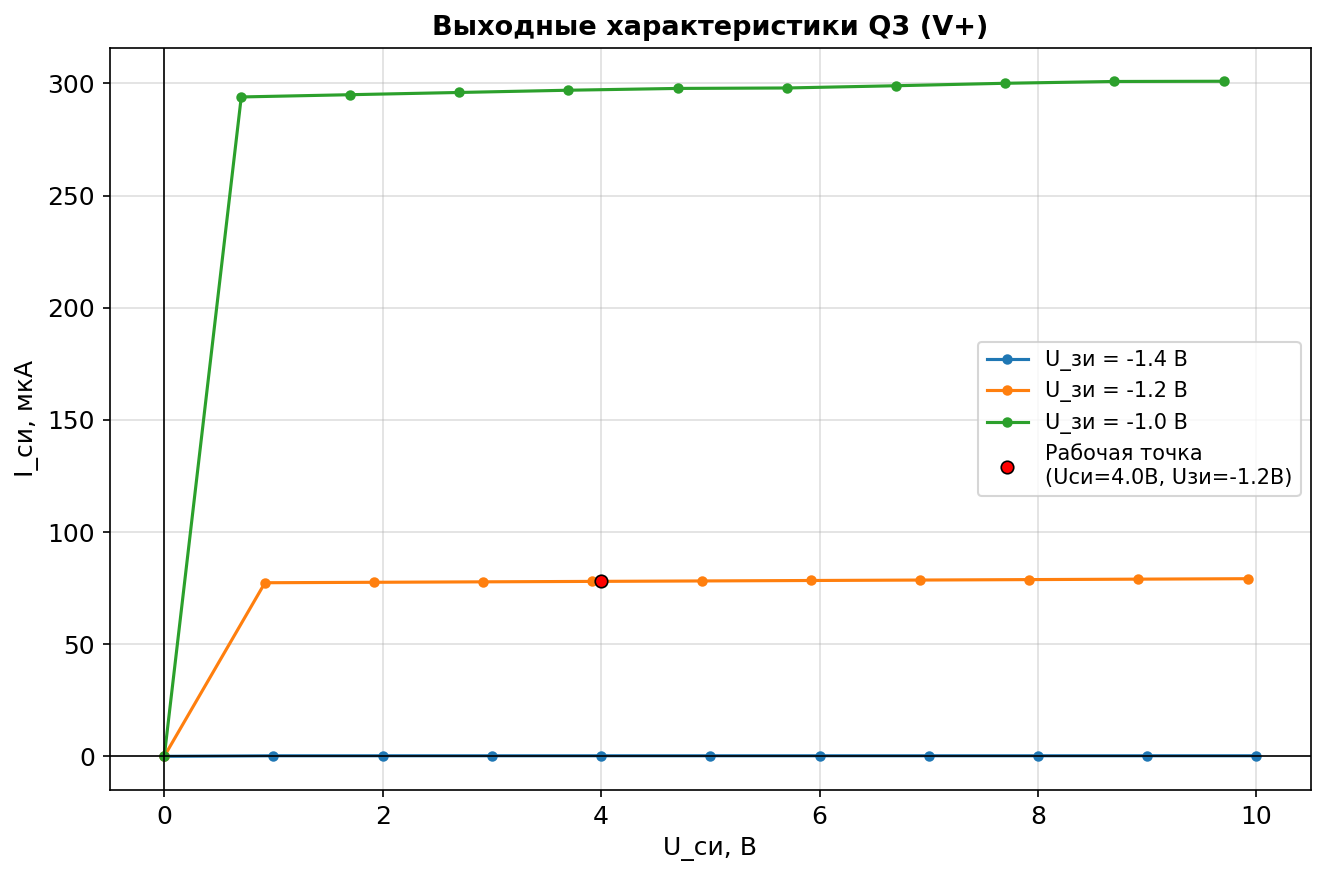

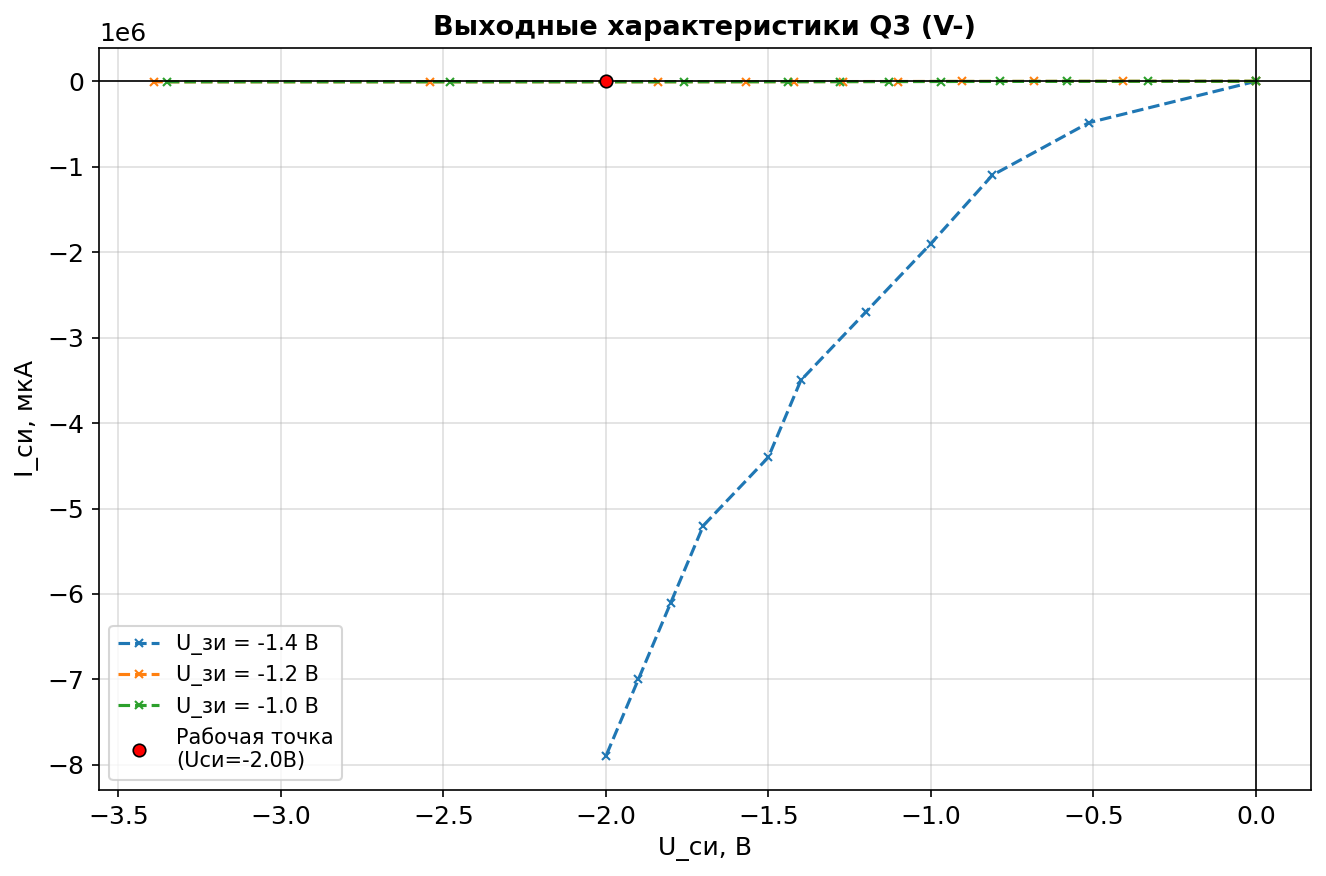

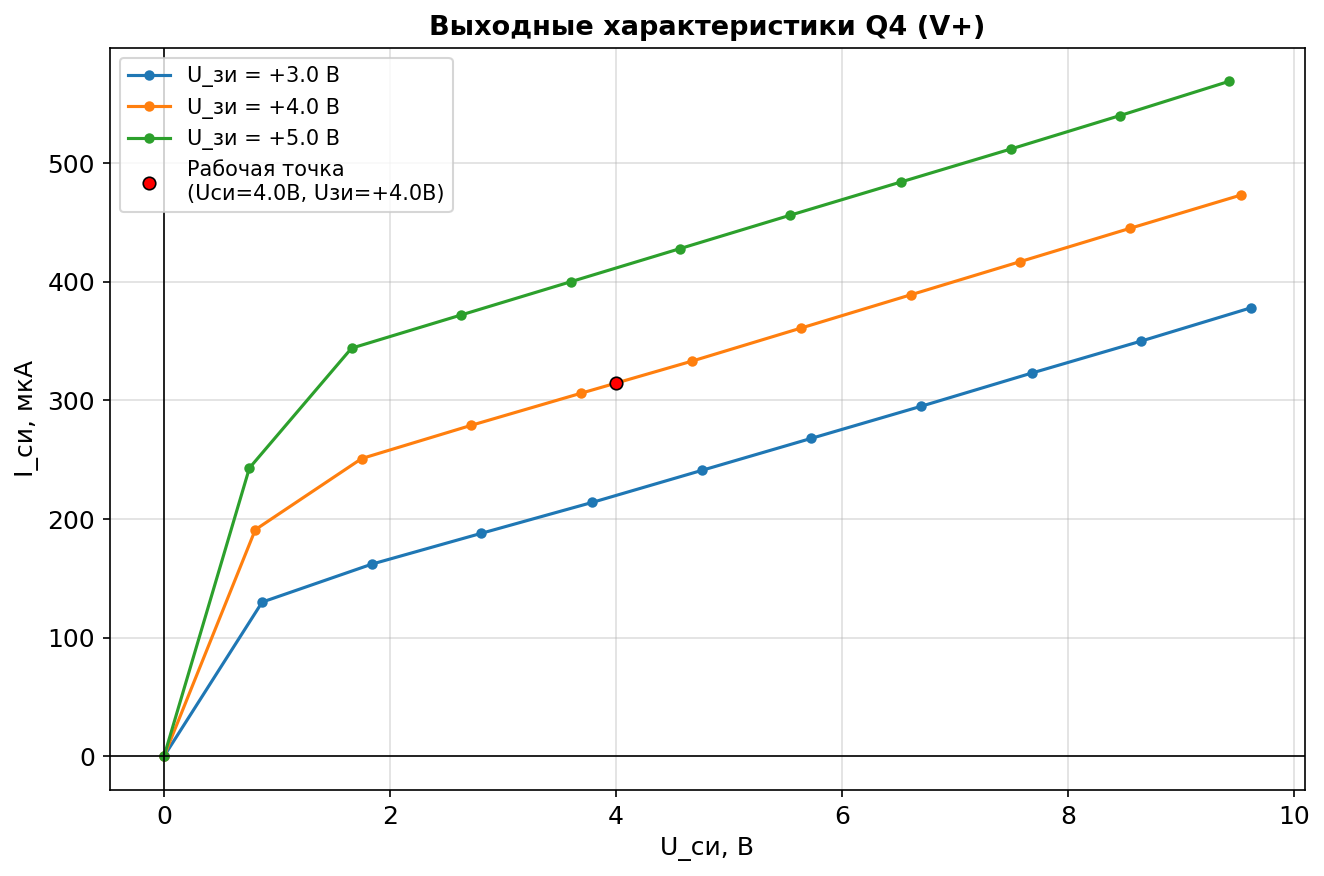

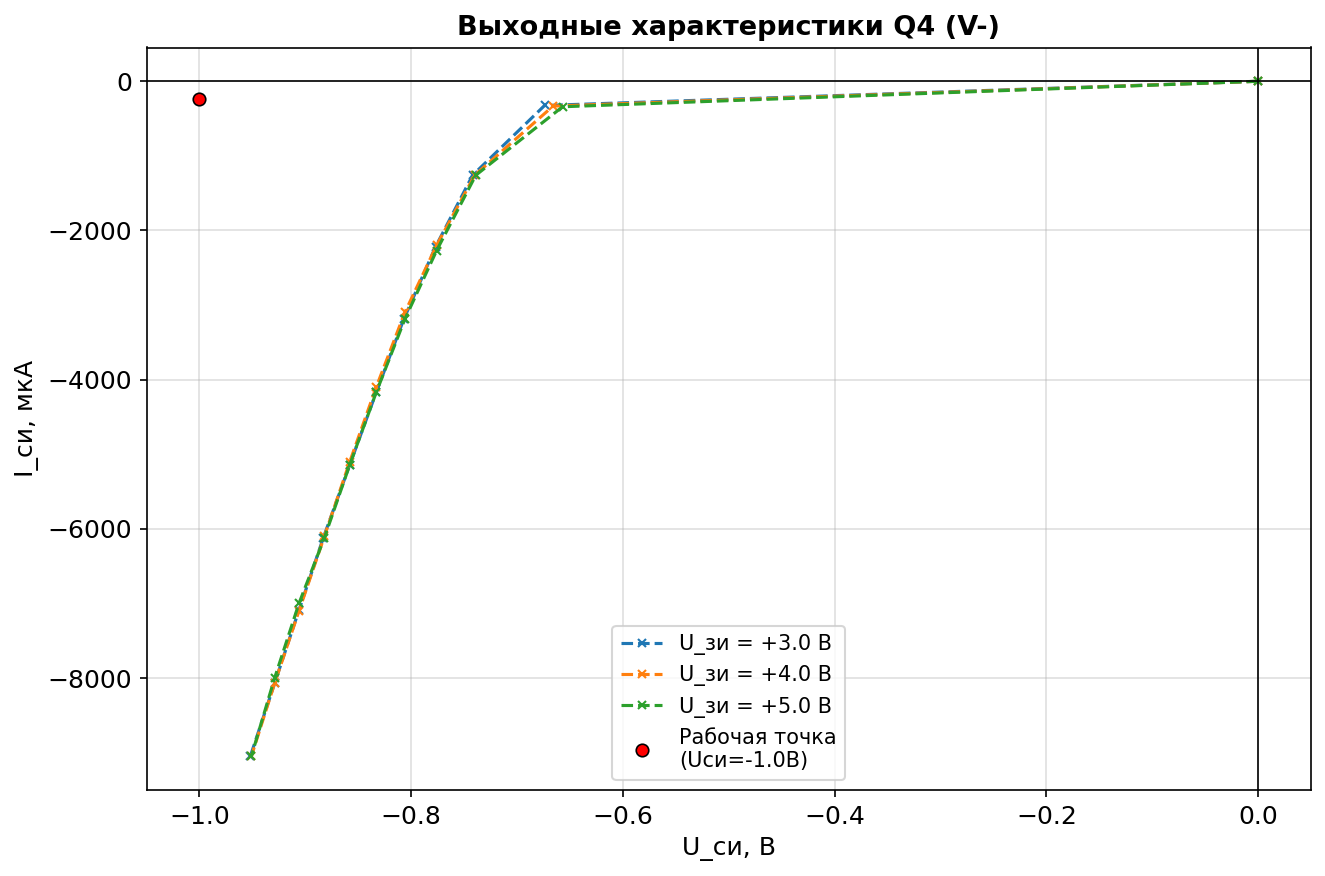


📈 Построение входных характеристик...


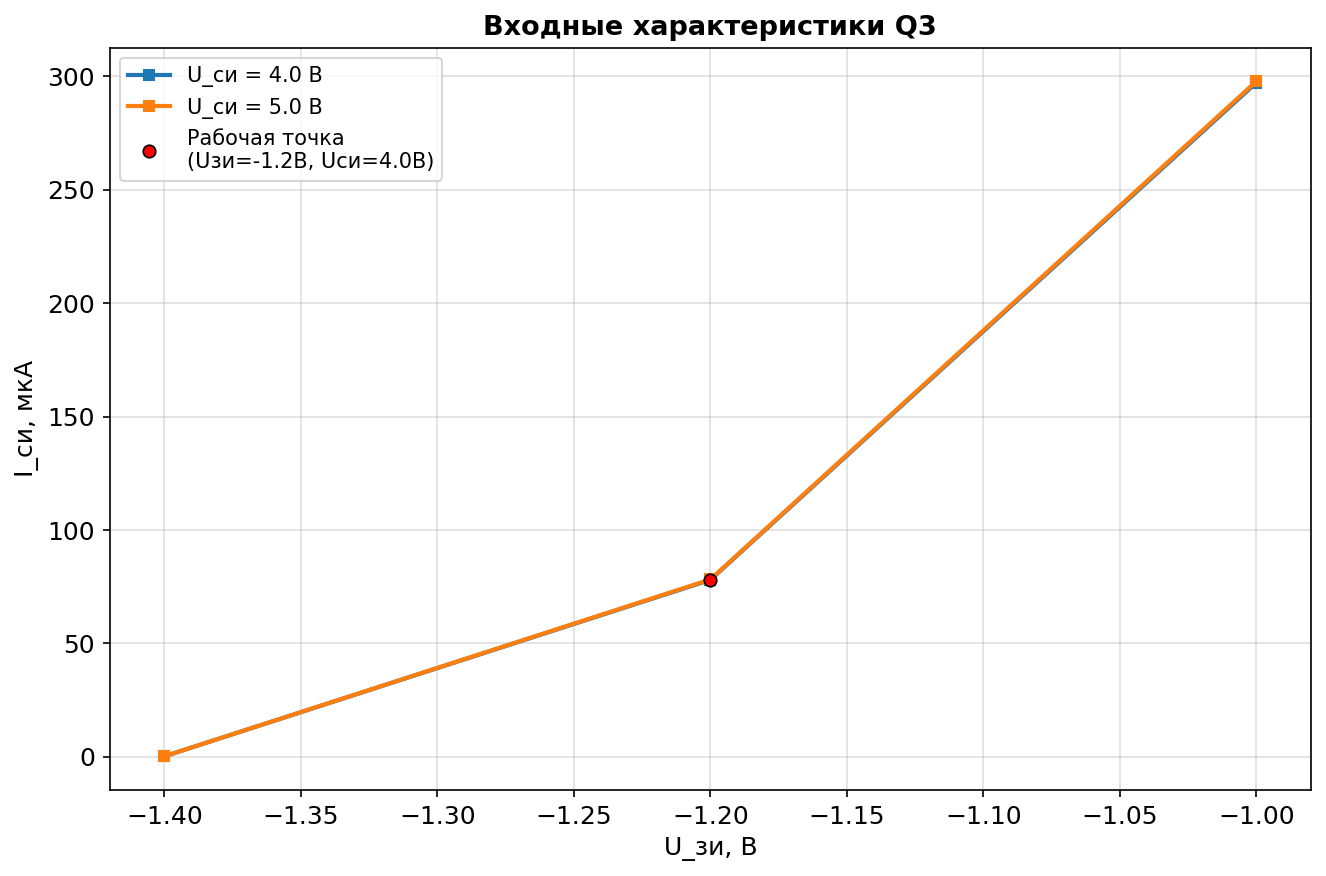

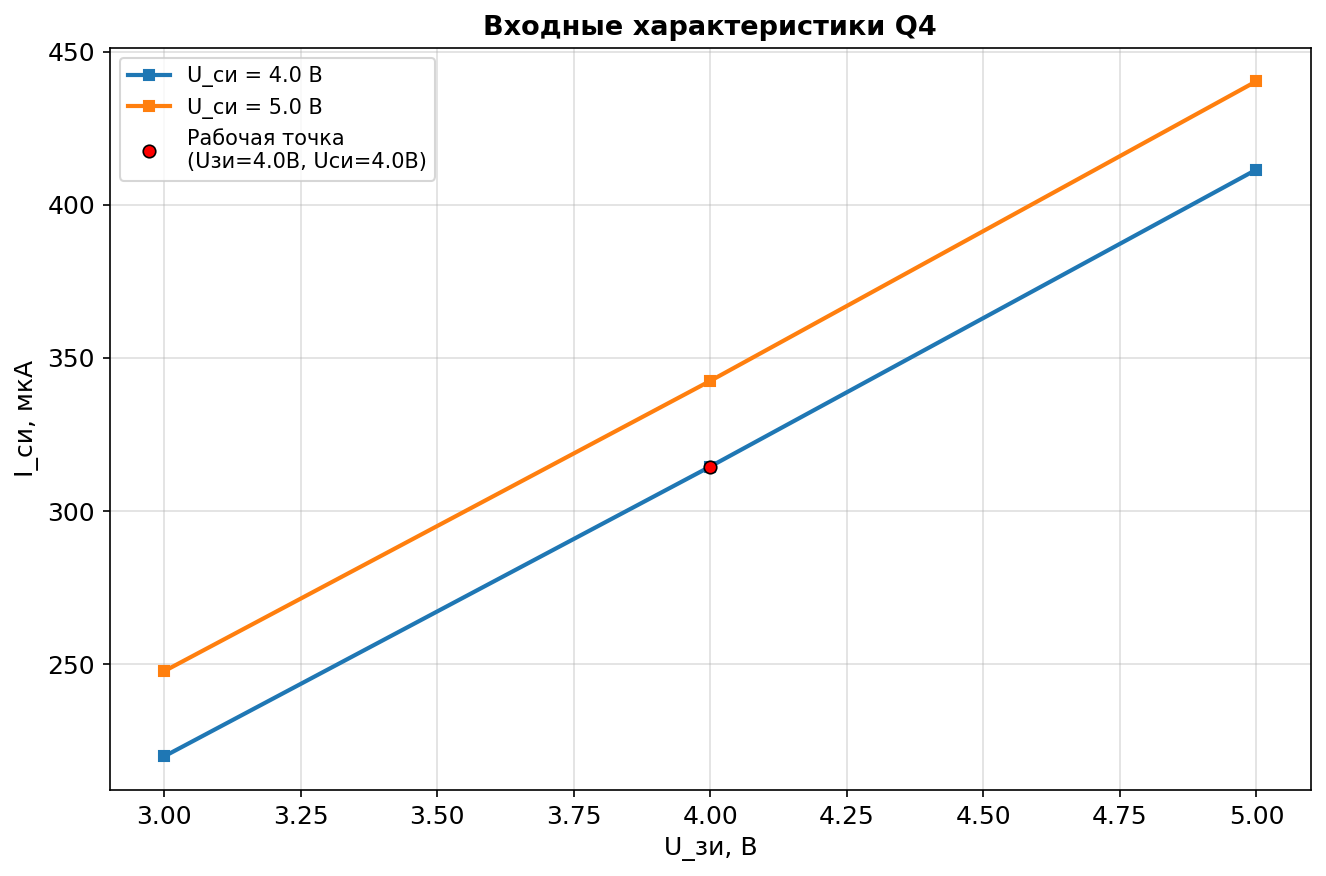


 РАСЧЁТ ПАРАМЕТРОВ УСИЛИТЕЛЯ

📊 Q3 (BF245A) | Расчёт при U_си = 4.0 В

1️⃣ Крутизна переходной характеристики S = dI_си/dU_зи:
   U_зи = -1.4 В → S = 388.8045 мкА/В
   U_зи = -1.2 В → S = 742.4623 мкА/В
   U_зи = -1.0 В → S = 1096.1200 мкА/В
   → Среднее: S = 742.4623 мкА/В = 0.742462 мА/В

2️⃣ Внутреннее сопротивление R = dU_си/dI_си (при U_зи = -1.2 В):
   → R ≈ 5000.00 МОм

3️⃣ Коэффициент усиления μ = S × R:
   μ = 742.4623 × 5000.00 = 3712311.25 (безразмерный)

📍 Ток в рабочей точке (Uси=4.0В): I_си = 78.02 мкА

📊 Q4 (Noname) | Расчёт при U_си = 4.0 В

1️⃣ Крутизна переходной характеристики S = dI_си/dU_зи:
   U_зи = +3.0 В → S = 94.6955 мкА/В
   U_зи = +4.0 В → S = 95.8505 мкА/В
   U_зи = +5.0 В → S = 97.0056 мкА/В
   → Среднее: S = 95.8505 мкА/В = 0.095851 мА/В

2️⃣ Внутреннее сопротивление R = dU_си/dI_си (при U_зи = +4.0 В):
   → R ≈ 34.75 МОм

3️⃣ Коэффициент усиления μ = S × R:
   μ = 95.8505 × 34.75 = 3330.77 (безразмерный)

📍 Ток в рабочей точке (Uси=4.0В): I_си = 314.54 

In [2]:
# -*- coding: utf-8 -*-
"""
Лабораторная работа: Изучение характеристик полевых транзисторов
Вариант 17 | Полный комплект (Графики + Расчёты)
Студент: Мэттью Риммер | Группа: БББО-23-24
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# ==================== НАСТРОЙКИ ====================
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['figure.dpi'] = 150
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Рабочие точки (Uси = 4В согласно варианту)
Q3_QPOINT = {'Ugs': -1.2, 'Uds': 4.0}  # Q3: Uзи = -1.2В, Uси = 4В
Q4_QPOINT = {'Ugs': 4.0, 'Uds': 4.0}   # Q4: Uзи = 4.0В, Uси = 4В

# ==================== ДАННЫЕ (ЕДИНЫЕ ЕДИНИЦЫ: мкА) ====================

# Q3 (BF245A)
# Опыт 5 (V+, -1.0В)
q3_v10_pU = np.array([0, 0.705, 1.7, 2.7, 3.7, 4.7, 5.7, 6.7, 7.7, 8.7, 9.7])
q3_v10_pI = np.array([0, 294, 295, 296, 297, 297.8, 298, 299, 300.1, 300.9, 301])

# Опыт 6 (V-, -1.0В)
q3_v10_mU = np.array([0, -0.331, -0.580, -0.787, -0.969, -1.13, -1.28, -1.44, -1.76, -2.48, -3.35])
q3_v10_mI = np.array([0, -668, -1400, -2300, -3000, -3800, -4700, -5500, -6200, -6500, -6600])

# Опыт 7 (V+, -1.2В)
q3_v12_pU = np.array([0, 0.922, 1.92, 2.92, 3.92, 4.92, 5.92, 6.92, 7.92, 8.92, 9.92])
q3_v12_pI = np.array([0, 77.4, 77.6, 77.8, 78, 78.2, 78.4, 78.6, 78.8, 79, 79.2])

# Опыт 8 (V-, -1.2В)
q3_v12_mU = np.array([0, -0.408, -0.682, -0.904, -1.1, -1.27, -1.42, -1.57, -1.84, -2.54, -3.39])
q3_v12_mI = np.array([0, -591, -1320, -2100, -2900, -3700, -4500, -5400, -6100, -6400, -6600])

# Опыт 9 (V+, -1.4В) [нА -> мкА]
q3_v14_pU = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
q3_v14_pI = np.array([0, 253.1, 253.7, 254.3, 255.1, 255.7, 256.4, 257.1, 257.7, 258.4, 259]) * 0.001

# Опыт 10 (V-, -1.4В) [мА -> мкА]
q3_v14_mU = np.array([0, -0.514, -0.811, -1.0, -1.2, -1.4, -1.5, -1.7, -1.8, -1.9, -2.0])
q3_v14_mI = np.array([0, -485, -1100, -1900, -2700, -3500, -4400, -5200, -6100, -7000, -7900]) * 1000

data_Q3 = {
    -1.0: (q3_v10_pU, q3_v10_pI, q3_v10_mU, q3_v10_mI),
    -1.2: (q3_v12_pU, q3_v12_pI, q3_v12_mU, q3_v12_mI),
    -1.4: (q3_v14_pU, q3_v14_pI, q3_v14_mU, q3_v14_mI)
}

# Q4 (Noname)
# Опыт 11 (V+, 3В)
q4_v3_pU = np.array([0, 0.869, 1.84, 2.81, 3.79, 4.76, 5.73, 6.70, 7.68, 8.65, 9.62])
q4_v3_pI = np.array([0, 130, 162, 188, 214, 241, 268, 295, 323, 350, 378])

# Опыт 12 (V-, 3В)
q4_v3_mU = np.array([0, -0.674, -0.742, -0.777, -0.807, -0.833, -0.858, -0.883, -0.906, -0.929, -0.952])
q4_v3_mI = np.array([0, -325, -1260, -2220, -3190, -4170, -5140, -6120, -7090, -8070, -9050])

# Опыт 13 (V+, 4В)
q4_v4_pU = np.array([0, 0.808, 1.75, 2.72, 3.69, 4.67, 5.64, 6.61, 7.58, 8.55, 9.53])
q4_v4_pI = np.array([0, 191, 251, 279, 306, 333, 361, 389, 417, 445, 473])

# Опыт 14 (V-, 4В)
q4_v4_mU = np.array([0, -0.666, -0.740, -0.776, -0.806, -0.833, -0.858, -0.882, -0.906, -0.929, -0.951])
q4_v4_mI = np.array([0, -333, -1260, -2200, -3100, -4100, -5100, -6100, -7100, -8070, -9050])

# Опыт 15 (V+, 5В)
q4_v5_pU = np.array([0, 0.756, 1.66, 2.63, 3.6, 4.57, 5.54, 6.52, 7.5, 8.46, 9.43])
q4_v5_pI = np.array([0, 243, 344, 372, 400, 428, 456, 484, 512, 540, 569])

# Опыт 16 (V-, 5В)
q4_v5_mU = np.array([0, -0.657, -0.739, -0.776, -0.806, -0.833, -0.858, -0.882, -0.906, -0.929, -0.951])
q4_v5_mI = np.array([0, -342, -1260, -2270, -3190, -4170, -5140, -6120, -7000, -8000, -9050])

data_Q4 = {
    3.0: (q4_v3_pU, q4_v3_pI, q4_v3_mU, q4_v3_mI),
    4.0: (q4_v4_pU, q4_v4_pI, q4_v4_mU, q4_v4_mI),
    5.0: (q4_v5_pU, q4_v5_pI, q4_v5_mU, q4_v5_mI)
}

# ==================== ФУНКЦИИ ГРАФИКОВ ====================

def plot_output_positive(data_dict, q_point, title, filename):
    """Выходные характеристики V+ с рабочей точкой"""
    plt.figure()
    for i, (Ugs, (Up, Ip, _, _)) in enumerate(sorted(data_dict.items())):
        plt.plot(Up, Ip, marker='o', markersize=4, label=f'U_зи = {Ugs:+.1f} В', 
                color=COLORS[i % len(COLORS)], linewidth=1.5)
    
    # Отмечаем рабочую точку
    ugs_q, uds_q = q_point['Ugs'], q_point['Uds']
    Up_q, Ip_q, _, _ = data_dict[ugs_q]
    f_interp = interp1d(Up_q, Ip_q, bounds_error=False, fill_value='extrapolate')
    ids_q = f_interp(uds_q)
    
    plt.plot(uds_q, ids_q, marker='o', markersize=6, color='red', 
            markeredgecolor='black', markeredgewidth=0.8, linewidth=0,
            label=f'Рабочая точка\n(Uси={uds_q}В, Uзи={ugs_q:+.1f}В)', zorder=10)
    
    plt.grid(True, alpha=0.4)
    plt.xlabel('U_си, В', fontsize=12)
    plt.ylabel('I_си, мкА', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

def plot_output_negative(data_dict, q_uds_neg, title, filename):
    """Выходные характеристики V- с рабочей точкой"""
    plt.figure()
    for i, (Ugs, (_, _, Um, Im)) in enumerate(sorted(data_dict.items())):
        plt.plot(Um, Im, marker='x', markersize=4, linestyle='--', label=f'U_зи = {Ugs:+.1f} В', 
                color=COLORS[i % len(COLORS)], linewidth=1.5)
    
    # Отмечаем рабочую точку
    ugs_q = -1.2 if "Q3" in title else 4.0
    Um_q, Im_q, _, _ = data_dict[ugs_q]
    f_interp = interp1d(Um_q, Im_q, bounds_error=False, fill_value='extrapolate')
    ids_q = f_interp(q_uds_neg)
    
    plt.plot(q_uds_neg, ids_q, marker='o', markersize=6, color='red', 
            markeredgecolor='black', markeredgewidth=0.8, linewidth=0,
            label=f'Рабочая точка\n(Uси={q_uds_neg}В)', zorder=10)
    
    plt.grid(True, alpha=0.4)
    plt.xlabel('U_си, В', fontsize=12)
    plt.ylabel('I_си, мкА', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

def plot_input_characteristics(data_dict, uds_targets, q_ugs, title, filename):
    """Входные характеристики с рабочей точкой НА ЛИНИИ Uси=4В"""
    plt.figure(figsize=(9, 6))
    
    # 1. Строим кривые
    for uds_target in uds_targets:
        ugs_values = []
        ids_values = []
        for ugs in sorted(data_dict.keys()):
            Up, Ip, _, _ = data_dict[ugs]
            f_interp = interp1d(Up, Ip, bounds_error=False, fill_value='extrapolate')
            ids_at_target = f_interp(uds_target)
            ugs_values.append(ugs)
            ids_values.append(ids_at_target)
        plt.plot(ugs_values, ids_values, marker='s', markersize=5, linewidth=2, 
                label=f'U_си = {uds_target} В')
    
    # 2. Находим координаты рабочей точки СТРОГО для кривой Uси = 4В
    uds_q = 4.0
    # Собираем данные для входной характеристики при Uси=4В
    ugs_list = sorted(data_dict.keys())
    ids_at_4v = []
    for ugs in ugs_list:
        Up, Ip, _, _ = data_dict[ugs]
        f = interp1d(Up, Ip, bounds_error=False, fill_value='extrapolate')
        ids_at_4v.append(f(4.0))
    
    # Интерполируем, чтобы найти Iси при нужном Uзи (q_ugs) на кривой 4В
    f_input_char = interp1d(ugs_list, ids_at_4v, bounds_error=False, fill_value='extrapolate')
    ids_q = f_input_char(q_ugs)
    
    # 3. Отмечаем точку
    plt.plot(q_ugs, ids_q, marker='o', markersize=6, color='red', 
            markeredgecolor='black', markeredgewidth=0.8, linewidth=0,
            label=f'Рабочая точка\n(Uзи={q_ugs}В, Uси={uds_q}В)', zorder=10)
    
    plt.grid(True, alpha=0.4)
    plt.xlabel('U_зи, В', fontsize=12)
    plt.ylabel('I_си, мкА', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

# ==================== РАСЧЁТ ПАРАМЕТРОВ ====================

def calculate_parameters(data_dict, name, uds_calc=4.0):
    """Расчёт S, R, μ для указанного транзистора"""
    print(f"\n{'='*60}")
    print(f"📊 {name} | Расчёт при U_си = {uds_calc} В")
    print(f"{'='*60}")
    
    # 1. Крутизна S = dI_си/dU_зи при U_си = const
    ugs_list = sorted(data_dict.keys())
    ids_at_uds = []
    for ugs in ugs_list:
        Up, Ip, _, _ = data_dict[ugs]
        f = interp1d(Up, Ip, bounds_error=False, fill_value='extrapolate')
        ids_at_uds.append(f(uds_calc))
    
    S_vals = np.gradient(ids_at_uds, ugs_list)
    S_avg = np.mean(np.abs(S_vals))
    
    print(f"\n1️⃣ Крутизна переходной характеристики S = dI_си/dU_зи:")
    for i, ugs in enumerate(ugs_list):
        print(f"   U_зи = {ugs:+.1f} В → S = {S_vals[i]:.4f} мкА/В")
    print(f"   → Среднее: S = {S_avg:.4f} мкА/В = {S_avg/1000:.6f} мА/В")
    
    # 2. Внутреннее сопротивление R = dU_си/dI_си при U_зи = const
    ugs_mid = ugs_list[len(ugs_list)//2]
    Up, Ip, _, _ = data_dict[ugs_mid]
    # Берём область насыщения (U_си > 6В)
    mask = Up > 6.0
    if np.sum(mask) >= 3:
        u_work = Up[mask]
        i_work = Ip[mask]
        # Аппроксимация полиномом 2-й степени
        coeffs = np.polyfit(u_work, i_work, 2)
        poly = np.poly1d(coeffs)
        di_du = np.polyder(poly)  # dI/dU
        R_avg = 1000 / np.mean(np.abs(di_du(u_work)))  # R = 1/(dI/dU) в МОм
        
        print(f"\n2️⃣ Внутреннее сопротивление R = dU_си/dI_си (при U_зи = {ugs_mid:+.1f} В):")
        print(f"   → R ≈ {R_avg:.2f} МОм")
        
        # 3. Коэффициент усиления μ = S × R
        mu = S_avg * R_avg
        print(f"\n3️⃣ Коэффициент усиления μ = S × R:")
        print(f"   μ = {S_avg:.4f} × {R_avg:.2f} = {mu:.2f} (безразмерный)")
        
        # Ток в рабочей точке для отчёта
        f_op = interp1d(Up, Ip, bounds_error=False, fill_value='extrapolate')
        ids_op = f_op(4.0)
        print(f"\n📍 Ток в рабочей точке (Uси=4.0В): I_си = {ids_op:.2f} мкА")
        
        return S_avg, R_avg, mu
    else:
        print("\n2️⃣ R: расчёт затруднён (малый диапазон насыщения)")
        return S_avg, None, None

# ==================== ЗАПУСК ====================

if __name__ == "__main__":
    print("🔬 ЛАБОРАТОРНАЯ РАБОТА: Вариант 17 | Полный расчёт")
    print("📌 Рабочие точки: Q3(Uзи=-1.2В, Uси=4.0В) | Q4(Uзи=4.0В, Uси=4.0В)")
    print("📏 Единицы тока: мкА (единые)")
    print("📍 Рабочая точка отмечена маленькой красной точкой")
    
    # 1. ВЫХОДНЫЕ ХАРАКТЕРИСТИКИ
    print("\n📈 Построение выходных характеристик...")
    plot_output_positive(data_Q3, Q3_QPOINT, "Выходные характеристики Q3 (V+)", "out_q3_plus.png")
    plot_output_negative(data_Q3, -2.0, "Выходные характеристики Q3 (V-)", "out_q3_minus.png")
    
    plot_output_positive(data_Q4, Q4_QPOINT, "Выходные характеристики Q4 (V+)", "out_q4_plus.png")
    plot_output_negative(data_Q4, -1.0, "Выходные характеристики Q4 (V-)", "out_q4_minus.png")
    
    # 2. ВХОДНЫЕ ХАРАКТЕРИСТИКИ
    print("\n📈 Построение входных характеристик...")
    plot_input_characteristics(data_Q3, [4.0, 5.0], -1.2, "Входные характеристики Q3", "in_q3.png")
    plot_input_characteristics(data_Q4, [4.0, 5.0], 4.0, "Входные характеристики Q4", "in_q4.png")
    
    # 3. РАСЧЁТ ПАРАМЕТРОВ
    print("\n РАСЧЁТ ПАРАМЕТРОВ УСИЛИТЕЛЯ")
    calc_Q3 = calculate_parameters(data_Q3, "Q3 (BF245A)", uds_calc=4.0)
    calc_Q4 = calculate_parameters(data_Q4, "Q4 (Noname)", uds_calc=4.0)
    
    print("\n" + "="*60)
    print("✅ ВСЕ ГРАФИКИ И РАСЧЁТЫ ВЫПОЛНЕНЫ!")
    print("📁 Файлы сохранены: out_q3_*.png, out_q4_*.png, in_q3.png, in_q4.png")
    print("="*60)

In [3]:
# -*- coding: utf-8 -*-
"""
Лабораторная работа: Изучение характеристик полевых транзисторов
Вариант 17 | ПОДРОБНЫЕ РАСЧЁТЫ ДЛЯ ОТЧЁТА
Студент: Мэттью Риммер | Группа: БББО-23-24
"""

import numpy as np
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# ==================== ДАННЫЕ (все токи в мкА) ====================

# Q3 (BF245A) - данные для положительной ветви
q3_ugs = np.array([-1.0, -1.2, -1.4])  # В

# Опыт 5: Uзи = -1.0В (V+)
q3_v10_U = np.array([0, 0.705, 1.7, 2.7, 3.7, 4.7, 5.7, 6.7, 7.7, 8.7, 9.7])
q3_v10_I = np.array([0, 294, 295, 296, 297, 297.8, 298, 299, 300.1, 300.9, 301])

# Опыт 7: Uзи = -1.2В (V+)
q3_v12_U = np.array([0, 0.922, 1.92, 2.92, 3.92, 4.92, 5.92, 6.92, 7.92, 8.92, 9.92])
q3_v12_I = np.array([0, 77.4, 77.6, 77.8, 78, 78.2, 78.4, 78.6, 78.8, 79, 79.2])

# Опыт 9: Uзи = -1.4В (V+) [нА → мкА]
q3_v14_U = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
q3_v14_I = np.array([0, 253.1, 253.7, 254.3, 255.1, 255.7, 256.4, 257.1, 257.7, 258.4, 259]) * 0.001

data_Q3 = {
    -1.0: (q3_v10_U, q3_v10_I),
    -1.2: (q3_v12_U, q3_v12_I),
    -1.4: (q3_v14_U, q3_v14_I)
}

# Q4 (Noname) - данные для положительной ветви
q4_ugs = np.array([3.0, 4.0, 5.0])  # В

# Опыт 11: Uзи = 3В (V+)
q4_v3_U = np.array([0, 0.869, 1.84, 2.81, 3.79, 4.76, 5.73, 6.70, 7.68, 8.65, 9.62])
q4_v3_I = np.array([0, 130, 162, 188, 214, 241, 268, 295, 323, 350, 378])

# Опыт 13: Uзи = 4В (V+)
q4_v4_U = np.array([0, 0.808, 1.75, 2.72, 3.69, 4.67, 5.64, 6.61, 7.58, 8.55, 9.53])
q4_v4_I = np.array([0, 191, 251, 279, 306, 333, 361, 389, 417, 445, 473])

# Опыт 15: Uзи = 5В (V+)
q4_v5_U = np.array([0, 0.756, 1.66, 2.63, 3.6, 4.57, 5.54, 6.52, 7.5, 8.46, 9.43])
q4_v5_I = np.array([0, 243, 344, 372, 400, 428, 456, 484, 512, 540, 569])

data_Q4 = {
    3.0: (q4_v3_U, q4_v3_I),
    4.0: (q4_v4_U, q4_v4_I),
    5.0: (q4_v5_U, q4_v5_I)
}

# ==================== ФУНКЦИИ РАСЧЁТА ====================

def format_num(val, decimals=3):
    """Форматирование числа для отчёта"""
    return f"{val:.{decimals}f}"

def calculate_transconductance_detailed(data_dict, ugs_list, uds_target, transistor_name):
    """
    Подробный расчёт крутизны S = dI_си/dU_зи при U_си = const
    """
    print(f"\n{'='*70}")
    print(f"1️⃣ РАСЧЁТ КРУТИЗНЫ S = dI_си/dU_зи при U_си = {uds_target} В")
    print(f"   Транзистор: {transistor_name}")
    print(f"{'='*70}")
    
    # Шаг 1: Интерполяция токов при заданном U_си
    print(f"\n📋 Шаг 1: Определение токов стока при U_си = {uds_target} В:")
    print(f"   {'U_зи, В':>10} | {'I_си, мкА':>12} | {'Источник'}")
    print(f"   {'-'*10} + {'-'*12} + {'-'*15}")
    
    ids_values = []
    for ugs in ugs_list:
        U_data, I_data = data_dict[ugs]
        f_interp = interp1d(U_data, I_data, kind='linear', bounds_error=False, fill_value='extrapolate')
        ids_at_target = f_interp(uds_target)
        ids_values.append(ids_at_target)
        print(f"   {ugs:+10.1f} | {ids_at_target:12.3f} | интерполяция")
    
    # Шаг 2: Расчёт производных (численное дифференцирование)
    print(f"\n📋 Шаг 2: Численное дифференцирование (метод центральных разностей):")
    print(f"   Формула: Sᵢ = (Iᵢ₊₁ - Iᵢ₋₁) / (Uᵢ₊₁ - Uᵢ₋₁)")
    print(f"   {'U_зи, В':>10} | {'ΔI_си, мкА':>12} | {'ΔU_зи, В':>10} | {'S, мкА/В':>12}")
    print(f"   {'-'*10} + {'-'*12} + {'-'*10} + {'-'*12}")
    
    S_values = np.gradient(ids_values, ugs_list)
    
    for i, ugs in enumerate(ugs_list):
        if i == 0:  # Левая граница: прямая разность
            dI = ids_values[1] - ids_values[0]
            dU = ugs_list[1] - ugs_list[0]
        elif i == len(ugs_list) - 1:  # Правая граница: обратная разность
            dI = ids_values[-1] - ids_values[-2]
            dU = ugs_list[-1] - ugs_list[-2]
        else:  # Центральная разность
            dI = ids_values[i+1] - ids_values[i-1]
            dU = ugs_list[i+1] - ugs_list[i-1]
        print(f"   {ugs:+10.1f} | {dI:12.3f} | {dU:10.3f} | {S_values[i]:12.4f}")
    
    # Шаг 3: Среднее значение
    S_avg = np.mean(np.abs(S_values))
    print(f"\n📋 Шаг 3: Среднее значение крутизны:")
    print(f"   S_ср = (|{format_num(S_values[0])}| + |{format_num(S_values[1])}| + |{format_num(S_values[2])}|) / 3")
    print(f"   S_ср = {format_num(np.abs(S_values[0])) + ' + ' + format_num(np.abs(S_values[1])) + ' + ' + format_num(np.abs(S_values[2]))} / 3")
    print(f"   S_ср = {format_num(S_avg)} мкА/В = {format_num(S_avg/1000, 6)} мА/В")
    
    return S_avg, ids_values

def calculate_output_resistance_detailed(data_dict, ugs_value, transistor_name):
    """
    Подробный расчёт внутреннего сопротивления R = dU_си/dI_си при U_зи = const
    """
    print(f"\n{'='*70}")
    print(f"2️⃣ РАСЧЁТ ВНУТРЕННЕГО СОПРОТИВЛЕНИЯ R = dU_си/dI_си")
    print(f"   Транзистор: {transistor_name}, U_зи = {ugs_value:+.1f} В")
    print(f"{'='*70}")
    
    U_data, I_data = data_dict[ugs_value]
    
    # Шаг 1: Выбор области насыщения
    print(f"\n📋 Шаг 1: Выделение области насыщения (U_си > 6 В):")
    mask = U_data > 6.0
    U_sat = U_data[mask]
    I_sat = I_data[mask]
    
    print(f"   Точки в области насыщения:")
    print(f"   {'№':>3} | {'U_си, В':>10} | {'I_си, мкА':>12}")
    print(f"   {'-'*3} + {'-'*10} + {'-'*12}")
    for i, (u, i_val) in enumerate(zip(U_sat, I_sat), 1):
        print(f"   {i:3d} | {u:10.3f} | {i_val:12.3f}")
    
    # Шаг 2: Аппроксимация полиномом
    print(f"\n📋 Шаг 2: Аппроксимация полиномом 2-й степени:")
    coeffs = np.polyfit(U_sat, I_sat, 2)
    print(f"   I_си(U_си) = a·U_си² + b·U_си + c")
    print(f"   a = {format_num(coeffs[0], 6)} мкА/В²")
    print(f"   b = {format_num(coeffs[1], 6)} мкА/В")
    print(f"   c = {format_num(coeffs[2], 6)} мкА")
    
    # Шаг 3: Производная и расчёт R
    print(f"\n📋 Шаг 3: Расчёт производной и внутреннего сопротивления:")
    print(f"   dI_си/dU_си = 2a·U_си + b")
    
    di_du_values = 2 * coeffs[0] * U_sat + coeffs[1]
    R_values = 1000 / np.maximum(np.abs(di_du_values), 1e-6)  # в МОм
    
    print(f"   {'U_си, В':>10} | {'dI/dU, мкА/В':>14} | {'R, МОм':>12}")
    print(f"   {'-'*10} + {'-'*14} + {'-'*12}")
    for u, di_du, r in zip(U_sat, di_du_values, R_values):
        print(f"   {u:10.3f} | {di_du:14.6f} | {r:12.2f}")
    
    R_avg = np.mean(R_values)
    print(f"\n📋 Шаг 4: Среднее значение сопротивления:")
    print(f"   R_ср = {format_num(R_avg)} МОм")
    
    return R_avg

def calculate_amplification_factor_detailed(S, R, transistor_name):
    """
    Подробный расчёт коэффициента усиления μ = S × R
    """
    print(f"\n{'='*70}")
    print(f"3️⃣ РАСЧЁТ КОЭФФИЦИЕНТА УСИЛЕНИЯ μ = S × R")
    print(f"   Транзистор: {transistor_name}")
    print(f"{'='*70}")
    
    print(f"\n📋 Формула: μ = S × R")
    print(f"   Где: S — крутизна [мкА/В], R — внутреннее сопротивление [МОм]")
    print(f"   Примечание: 1 мкА/В × 1 МОм = 1 (безразмерная величина)")
    
    print(f"\n📋 Подстановка значений:")
    print(f"   S = {format_num(S)} мкА/В")
    print(f"   R = {format_num(R)} МОм")
    print(f"   μ = {format_num(S)} × {format_num(R)} = {format_num(S * R, 2)}")
    
    return S * R

def calculate_working_point_detailed(data_dict, ugs_q, uds_q, transistor_name):
    """
    Расчёт координат рабочей точки
    """
    print(f"\n{'='*70}")
    print(f"📍 РАСЧЁТ КООРДИНАТ РАБОЧЕЙ ТОЧКИ")
    print(f"   Транзистор: {transistor_name}")
    print(f"{'='*70}")
    
    U_data, I_data = data_dict[ugs_q]
    f_interp = interp1d(U_data, I_data, bounds_error=False, fill_value='extrapolate')
    ids_q = f_interp(uds_q)
    
    print(f"\n📋 Дано:")
    print(f"   U_зи(раб) = {ugs_q:+.1f} В (из варианта 17)")
    print(f"   U_си(раб) = {uds_q:.1f} В (из варианта 17)")
    
    print(f"\n📋 Расчёт тока стока в рабочей точке:")
    print(f"   Используем интерполяцию экспериментальных данных")
    print(f"   I_си(раб) = f(U_си = {uds_q} В) при U_зи = {ugs_q:+.1f} В")
    print(f"   I_си(раб) = {format_num(ids_q, 2)} мкА")
    
    print(f"\n✅ Координаты рабочей точки:")
    print(f"   Q: (U_си = {uds_q} В, U_зи = {ugs_q:+.1f} В, I_си = {format_num(ids_q, 2)} мкА)")
    
    return ids_q

# ==================== ОСНОВНОЙ БЛОК ====================

if __name__ == "__main__":
    print("╔" + "═"*68 + "╗")
    print("║" + " "*15 + "ЛАБОРАТОРНАЯ РАБОТА №4" + " "*29 + "║")
    print("║" + " "*10 + "Вариант 17 | ПОДРОБНЫЕ РАСЧЁТЫ" + " "*26 + "║")
    print("║" + " "*18 + "Студент: Риммер М.В." + " "*26 + "║")
    print("╚" + "═"*68 + "╝")
    
    # Рабочие точки согласно варианту 17
    UDS_OPERATING = 4.0  # В
    Q3_QPOINT = {'Ugs': -1.2, 'Uds': UDS_OPERATING}
    Q4_QPOINT = {'Ugs': 4.0, 'Uds': UDS_OPERATING}
    
    # ==================== Q3 (BF245A) ====================
    print(f"\n\n{'#'*70}")
    print(f"# ТРАНЗИСТОР Q3: BF245A (с управляющим p-n переходом)")
    print(f"#{'#'*69}")
    
    # Рабочая точка
    ids_q3 = calculate_working_point_detailed(data_Q3, Q3_QPOINT['Ugs'], Q3_QPOINT['Uds'], "Q3 (BF245A)")
    
    # Крутизна S при U_си = 4В
    S_q3, _ = calculate_transconductance_detailed(data_Q3, q3_ugs, UDS_OPERATING, "Q3 (BF245A)")
    
    # Сопротивление R при U_зи = -1.2В
    R_q3 = calculate_output_resistance_detailed(data_Q3, Q3_QPOINT['Ugs'], "Q3 (BF245A)")
    
    # Коэффициент усиления μ
    mu_q3 = calculate_amplification_factor_detailed(S_q3, R_q3, "Q3 (BF245A)")
    
    # ==================== Q4 (Noname) ====================
    print(f"\n\n{'#'*70}")
    print(f"# ТРАНЗИСТОР Q4: Noname (с изолированным затвором)")
    print(f"#{'#'*69}")
    
    # Рабочая точка
    ids_q4 = calculate_working_point_detailed(data_Q4, Q4_QPOINT['Ugs'], Q4_QPOINT['Uds'], "Q4 (Noname)")
    
    # Крутизна S при U_си = 4В
    S_q4, _ = calculate_transconductance_detailed(data_Q4, q4_ugs, UDS_OPERATING, "Q4 (Noname)")
    
    # Сопротивление R при U_зи = 4В
    R_q4 = calculate_output_resistance_detailed(data_Q4, Q4_QPOINT['Ugs'], "Q4 (Noname)")
    
    # Коэффициент усиления μ
    mu_q4 = calculate_amplification_factor_detailed(S_q4, R_q4, "Q4 (Noname)")
    
    # ==================== СВОДНАЯ ТАБЛИЦА ====================
    print(f"\n\n{'='*70}")
    print("📋 СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ (для отчёта)")
    print(f"{'='*70}")
    
    print(f"\n{'Параметр':<25} | {'Q3 (BF245A)':>20} | {'Q4 (Noname)':>20}")
    print(f"{'-'*25} + {'-'*20} + {'-'*20}")
    print(f"{'Рабочая точка:':<25} | {'':>20} | {'':>20}")
    print(f"  U_зи, В:                | {Q3_QPOINT['Ugs']:+.1f}{'':>16} | {Q4_QPOINT['Ugs']:+.1f}{'':>16}")
    print(f"  U_си, В:                | {Q3_QPOINT['Uds']:.1f}{'':>17} | {Q4_QPOINT['Uds']:.1f}{'':>17}")
    print(f"  I_си, мкА:              | {ids_q3:>12.2f}{'':>8} | {ids_q4:>12.2f}{'':>8}")
    print(f"{'-'*25} + {'-'*20} + {'-'*20}")
    print(f"{'Крутизна S, мкА/В:':<25} | {S_q3:>12.4f}{'':>8} | {S_q4:>12.4f}{'':>8}")
    print(f"{'Крутизна S, мА/В:':<25} | {S_q3/1000:>12.6f}{'':>8} | {S_q4/1000:>12.6f}{'':>8}")
    print(f"{'Внутр. сопр. R, МОм:':<25} | {R_q3:>12.2f}{'':>8} | {R_q4:>12.2f}{'':>8}")
    print(f"{'Коэфф. усиления μ:':<25} | {mu_q3:>12.2f}{'':>8} | {mu_q4:>12.2f}{'':>8}")
    print(f"{'-'*25} + {'-'*20} + {'-'*20}")
    
    print(f"\n{'='*70}")
    print("✅ ВСЕ РАСЧЁТЫ ЗАВЕРШЕНЫ!")
    print("📝 Скопируйте результаты выше в раздел 'Расчёты' вашего отчёта.")
    print(f"{'='*70}")

╔════════════════════════════════════════════════════════════════════╗
║               ЛАБОРАТОРНАЯ РАБОТА №4                             ║
║          Вариант 17 | ПОДРОБНЫЕ РАСЧЁТЫ                          ║
║                  Студент: Риммер М.В.                          ║
╚════════════════════════════════════════════════════════════════════╝


######################################################################
# ТРАНЗИСТОР Q3: BF245A (с управляющим p-n переходом)
######################################################################

📍 РАСЧЁТ КООРДИНАТ РАБОЧЕЙ ТОЧКИ
   Транзистор: Q3 (BF245A)

📋 Дано:
   U_зи(раб) = -1.2 В (из варианта 17)
   U_си(раб) = 4.0 В (из варианта 17)

📋 Расчёт тока стока в рабочей точке:
   Используем интерполяцию экспериментальных данных
   I_си(раб) = f(U_си = 4.0 В) при U_зи = -1.2 В
   I_си(раб) = 78.02 мкА

✅ Координаты рабочей точки:
   Q: (U_си = 4.0 В, U_зи = -1.2 В, I_си = 78.02 мкА)

1️⃣ РАСЧЁТ КРУТИЗНЫ S = dI_си/dU_зи при U_си = 4.0 В
   Тран

In [4]:
# -*- coding: utf-8 -*-
"""
Лабораторная работа: Изучение характеристик полевых транзисторов
Вариант 17 | ПОДРОБНЫЕ РАСЧЁТЫ ПО ИЗВЕСТНЫМ ТОЧКАМ
Студент: Мэттью Риммер | Группа: БББО-23-24
"""

import numpy as np

# Форматирование чисел для красивого вывода
def fmt(val):
    return f"{val:.3f}"

# ==================== ИСХОДНЫЕ ДАННЫЕ ИЗ ТАБЛИЦ (Опыты) ====================
# Все токи приведены к мкА

# Q3 (BF245A)
# Опыт 5 (Uзи = -1.0В). Ближайшие точки к 4В: 3.7В и 4.7В
q3_10_U = np.array([3.7, 4.7])
q3_10_I = np.array([297.0, 297.8]) # мкА

# Опыт 7 (Uзи = -1.2В). Ближайшие точки к 4В: 3.92В и 4.92В
q3_12_U = np.array([3.92, 4.92])
q3_12_I = np.array([78.0, 78.2])   # мкА

# Опыт 9 (Uзи = -1.4В). Есть точная точка 4В! (Перевод из нА в мкА)
q3_14_U = np.array([3, 4, 5])
q3_14_I = np.array([0.2551, 0.2557, 0.2564]) # мкА (было 255.1 нА)

# Q4 (Noname)
# Опыт 11 (Uзи = 3В). Ближайшие точки к 4В: 3.79В и 4.76В
q4_3_U = np.array([3.79, 4.76])
q4_3_I = np.array([214, 241])      # мкА

# Опыт 13 (Uзи = 4В). Ближайшие точки к 4В: 3.69В и 4.67В
q4_4_U = np.array([3.69, 4.67])
q4_4_I = np.array([306, 333])      # мкА

# Опыт 15 (Uзи = 5В). Ближайшие точки к 4В: 3.6В и 4.57В
q4_5_U = np.array([3.6, 4.57])
q4_5_I = np.array([400, 428])      # мкА

# ==================== ФУНКЦИИ РАСЧЕТА ====================

def get_interpolated_current(U1, I1, U2, I2, U_target):
    """Линейная интерполяция между двумя известными точками"""
    # I = I1 + (I2 - I1) * (U_target - U1) / (U2 - U1)
    k = (I2 - I1) / (U2 - U1)
    I_target = I1 + k * (U_target - U1)
    return I_target, k

print("="*70)
print("📝 РАСЧЁТНАЯ ЧАСТЬ ДЛЯ ОТЧЕТА (Вариант 17)")
print("Рабочая точка: Uси = 4.0 В")
print("="*70)

# ==================== Q3 (BF245A) ====================
print("\n\n" + "="*70)
print("ТРАНЗИСТОР Q3: BF245A (с управляющим p-n переходом)")
print("Uзи по варианту: -1.0В; -1.2В; -1.4В")
print("="*70)

# 1. Определение токов при Uси = 4В
print("\n📍 Шаг 1: Определение тока стока Iси при Uси = 4В")
print("   Используем линейную интерполяцию между ближайшими измеренными точками:")

# Для Uзи = -1.0В (Опыт 5)
I_10, _ = get_interpolated_current(q3_10_U[0], q3_10_I[0], q3_10_U[1], q3_10_I[1], 4.0)
print(f"   • При Uзи = -1.0 В (Опыт 5):")
print(f"     Берем точки из таблицы: (U={q3_10_U[0]}В, I={q3_10_I[0]}мкА) и (U={q3_10_U[1]}В, I={q3_10_I[1]}мкА)")
print(f"     Iси(-1.0В) ≈ {fmt(I_10)} мкА")

# Для Uзи = -1.2В (Опыт 7)
I_12, _ = get_interpolated_current(q3_12_U[0], q3_12_I[0], q3_12_U[1], q3_12_I[1], 4.0)
print(f"   • При Uзи = -1.2 В (Опыт 7):")
print(f"     Берем точки из таблицы: (U={q3_12_U[0]}В, I={q3_12_I[0]}мкА) и (U={q3_12_U[1]}В, I={q3_12_I[1]}мкА)")
print(f"     Iси(-1.2В) ≈ {fmt(I_12)} мкА")

# Для Uзи = -1.4В (Опыт 9)
I_14 = q3_14_I[1] # Точная точка
print(f"   • При Uзи = -1.4 В (Опыт 9):")
print(f"     В таблице есть точная точка Uси = 4В")
print(f"     Iси(-1.4В) = {fmt(I_14)} мкА (255.7 нА)")

# 2. Расчет крутизны S
print("\n📈 Шаг 2: Расчет крутизны S = ΔIси / ΔUзи при Uси = 4В")
print("   Формула: S = (I2 - I1) / (U2 - U1)")

# Считаем S в двух точках и берем среднее
S1 = (I_12 - I_10) / (-1.2 - (-1.0))
S2 = (I_14 - I_12) / (-1.4 - (-1.2))
S_avg = (abs(S1) + abs(S2)) / 2

print(f"   Участок 1 (от -1.0 до -1.2В): S1 = ({fmt(I_12)} - {fmt(I_10)}) / (-1.2 - (-1.0)) = {fmt(S1)} мкА/В")
print(f"   Участок 2 (от -1.2 до -1.4В): S2 = ({fmt(I_14)} - {fmt(I_12)}) / (-1.4 - (-1.2)) = {fmt(S2)} мкА/В")
print(f"   → Средняя крутизна Sср = {fmt(S_avg)} мкА/В = {fmt(S_avg/1000)} мА/В")

# 3. Расчет внутреннего сопротивления R
print("\n💎 Шаг 3: Расчет внутреннего сопротивления R = ΔUси / ΔIси")
print("   Расчет производим для рабочей точки Uзи = -1.2 В (Опыт 7)")
print("   Используем точки, охватывающие Uси = 4В:")

R_q3 = (q3_12_U[1] - q3_12_U[0]) / (q3_12_I[1] - q3_12_I[0]) # kOhm? No, U/I -> MOhm if I is uA.
# U in V, I in uA. R = V / uA = 10^6 Ohm = MOhm.
# Let's be careful with units.
# R = (4.92 - 3.92) / (78.2 - 78.0) = 1 / 0.2 = 5 MOhm.

print(f"   Точки: (U={q3_12_U[0]}В, I={q3_12_I[0]}мкА) и (U={q3_12_U[1]}В, I={q3_12_I[1]}мкА)")
print(f"   ΔUси = {q3_12_U[1]} - {q3_12_U[0]} = {fmt(q3_12_U[1] - q3_12_U[0])} В")
print(f"   ΔIси = {q3_12_I[1]} - {q3_12_I[0]} = {fmt(q3_12_I[1] - q3_12_I[0])} мкА")
print(f"   R = ΔU / ΔI = {fmt(q3_12_U[1] - q3_12_U[0])} / {fmt(q3_12_I[1] - q3_12_I[0])} ≈ {fmt(R_q3)} МОм")

# 4. Коэффициент усиления
mu_q3 = S_avg * R_q3
print(f"\n🚀 Шаг 4: Коэффициент усиления μ = S × R")
print(f"   μ = {fmt(S_avg)} мкА/В × {fmt(R_q3)} МОм")
print(f"   μ ≈ {fmt(mu_q3)}")

# ==================== Q4 (Noname) ====================
print("\n\n" + "="*70)
print("ТРАНЗИСТОР Q4: Noname (с изолированным затвором)")
print("Uзи по варианту: 3В; 4В; 5В")
print("="*70)

# 1. Определение токов при Uси = 4В
print("\n Шаг 1: Определение тока стока Iси при Uси = 4В")

# Для Uзи = 3В (Опыт 11)
I_3, _ = get_interpolated_current(q4_3_U[0], q4_3_I[0], q4_3_U[1], q4_3_I[1], 4.0)
print(f"   • При Uзи = 3 В (Опыт 11): Интерполяция между {q4_3_U[0]}В и {q4_3_U[1]}В")
print(f"     Iси(3В) ≈ {fmt(I_3)} мкА")

# Для Uзи = 4В (Опыт 13)
I_4, _ = get_interpolated_current(q4_4_U[0], q4_4_I[0], q4_4_U[1], q4_4_I[1], 4.0)
print(f"   • При Uзи = 4 В (Опыт 13): Интерполяция между {q4_4_U[0]}В и {q4_4_U[1]}В")
print(f"     Iси(4В) ≈ {fmt(I_4)} мкА")

# Для Uзи = 5В (Опыт 15)
I_5, _ = get_interpolated_current(q4_5_U[0], q4_5_I[0], q4_5_U[1], q4_5_I[1], 4.0)
print(f"   • При Uзи = 5 В (Опыт 15): Интерполяция между {q4_5_U[0]}В и {q4_5_U[1]}В")
print(f"     Iси(5В) ≈ {fmt(I_5)} мкА")

# 2. Расчет крутизны S
print("\n📈 Шаг 2: Расчет крутизны S = ΔIси / ΔUзи при Uси = 4В")

S1_q4 = (I_4 - I_3) / (4 - 3)
S2_q4 = (I_5 - I_4) / (5 - 4)
S_avg_q4 = (S1_q4 + S2_q4) / 2

print(f"   Участок 1 (3-4В): S1 = ({fmt(I_4)} - {fmt(I_3)}) / 1 = {fmt(S1_q4)} мкА/В")
print(f"   Участок 2 (4-5В): S2 = ({fmt(I_5)} - {fmt(I_4)}) / 1 = {fmt(S2_q4)} мкА/В")
print(f"   → Средняя крутизна Sср = {fmt(S_avg_q4)} мкА/В = {fmt(S_avg_q4/1000)} мА/В")

# 3. Расчет внутреннего сопротивления R
print("\n💎 Шаг 3: Расчет внутреннего сопротивления R = ΔUси / ΔIси")
print("   Расчет производим для рабочей точки Uзи = 4 В (Опыт 13)")

R_q4 = (q4_4_U[1] - q4_4_U[0]) / (q4_4_I[1] - q4_4_I[0])
print(f"   Точки: (U={q4_4_U[0]}В, I={q4_4_I[0]}мкА) и (U={q4_4_U[1]}В, I={q4_4_I[1]}мкА)")
print(f"   ΔUси = {fmt(q4_4_U[1] - q4_4_U[0])} В")
print(f"   ΔIси = {q4_4_I[1]} - {q4_4_I[0]} = {q4_4_I[1] - q4_4_I[0]} мкА")
print(f"   R = {fmt(q4_4_U[1] - q4_4_U[0])} / {q4_4_I[1] - q4_4_I[0]} ≈ {fmt(R_q4)} МОм")

# 4. Коэффициент усиления
mu_q4 = S_avg_q4 * R_q4
print(f"\n🚀 Шаг 4: Коэффициент усиления μ = S × R")
print(f"   μ = {fmt(S_avg_q4)} × {fmt(R_q4)} ≈ {fmt(mu_q4)}")

print("\n" + "="*70)
print("✅ РАСЧЕТЫ ЗАВЕРШЕНЫ")
print("="*70)

📝 РАСЧЁТНАЯ ЧАСТЬ ДЛЯ ОТЧЕТА (Вариант 17)
Рабочая точка: Uси = 4.0 В


ТРАНЗИСТОР Q3: BF245A (с управляющим p-n переходом)
Uзи по варианту: -1.0В; -1.2В; -1.4В

📍 Шаг 1: Определение тока стока Iси при Uси = 4В
   Используем линейную интерполяцию между ближайшими измеренными точками:
   • При Uзи = -1.0 В (Опыт 5):
     Берем точки из таблицы: (U=3.7В, I=297.0мкА) и (U=4.7В, I=297.8мкА)
     Iси(-1.0В) ≈ 297.240 мкА
   • При Uзи = -1.2 В (Опыт 7):
     Берем точки из таблицы: (U=3.92В, I=78.0мкА) и (U=4.92В, I=78.2мкА)
     Iси(-1.2В) ≈ 78.016 мкА
   • При Uзи = -1.4 В (Опыт 9):
     В таблице есть точная точка Uси = 4В
     Iси(-1.4В) = 0.256 мкА (255.7 нА)

📈 Шаг 2: Расчет крутизны S = ΔIси / ΔUзи при Uси = 4В
   Формула: S = (I2 - I1) / (U2 - U1)
   Участок 1 (от -1.0 до -1.2В): S1 = (78.016 - 297.240) / (-1.2 - (-1.0)) = 1096.120 мкА/В
   Участок 2 (от -1.2 до -1.4В): S2 = (0.256 - 78.016) / (-1.4 - (-1.2)) = 388.802 мкА/В
   → Средняя крутизна Sср = 742.461 мкА/В = 0.742 мА/В

💎 Ша

🔬 Лабораторная работа: Вариант 17
📌 Рабочие точки: Q3(Uзи=-1.2В, Uси=4.0В) | Q4(Uзи=4.0В, Uси=4.0В)
📊 На графиках отмечены ВСЕ измеренные точки
📈 Только положительные ветви (V+)

📈 Построение выходных характеристик (V+)...


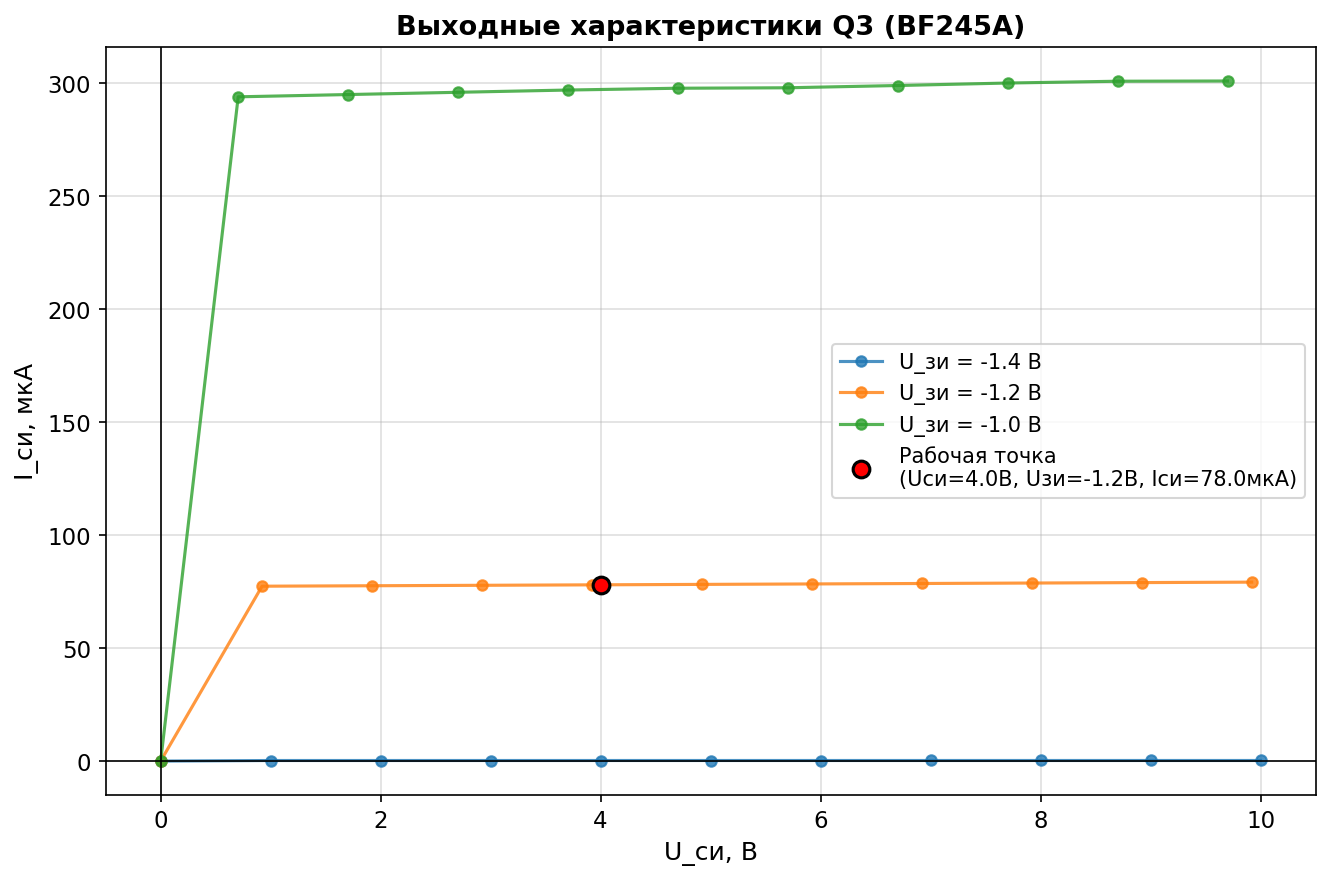

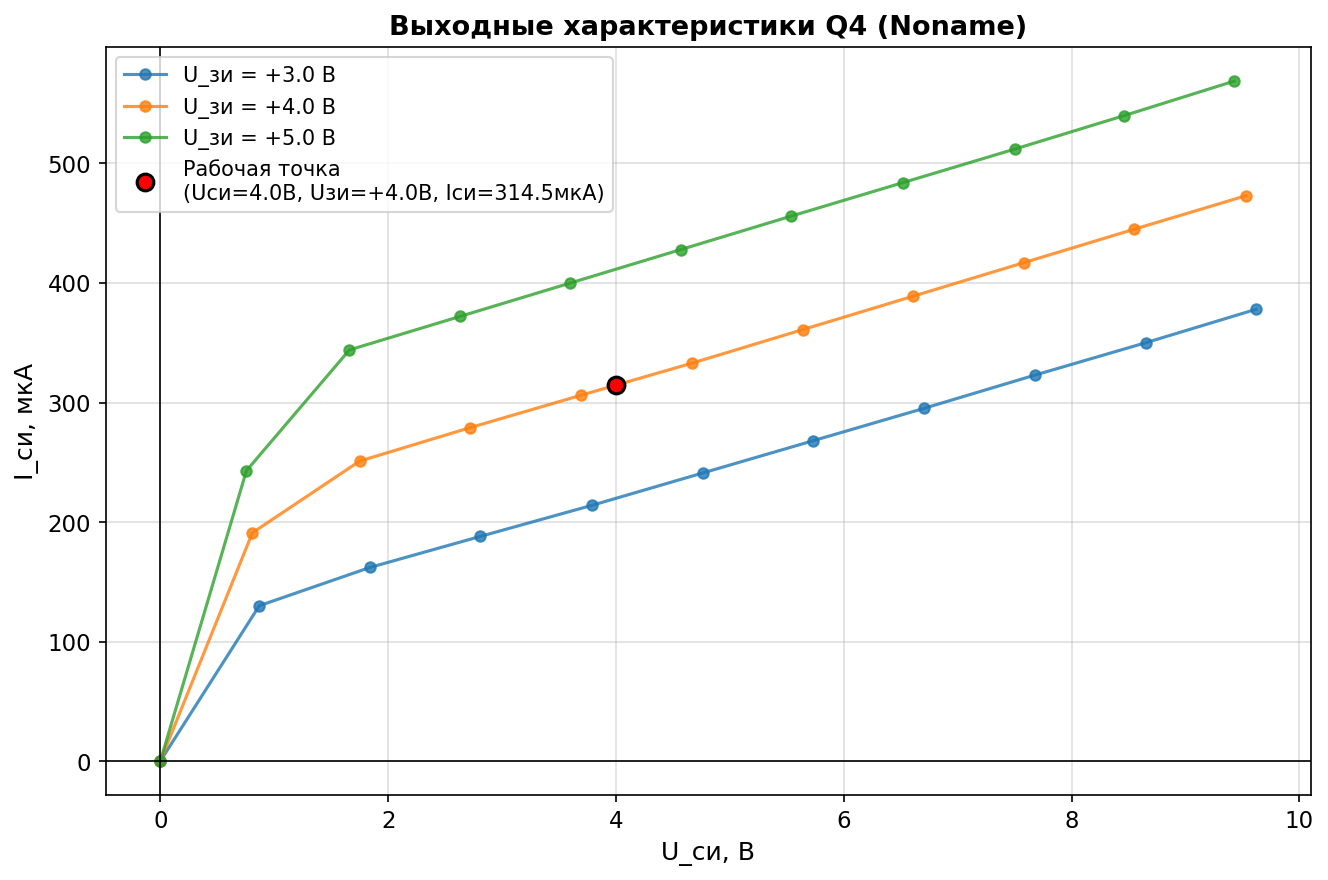


📈 Построение входных характеристик...


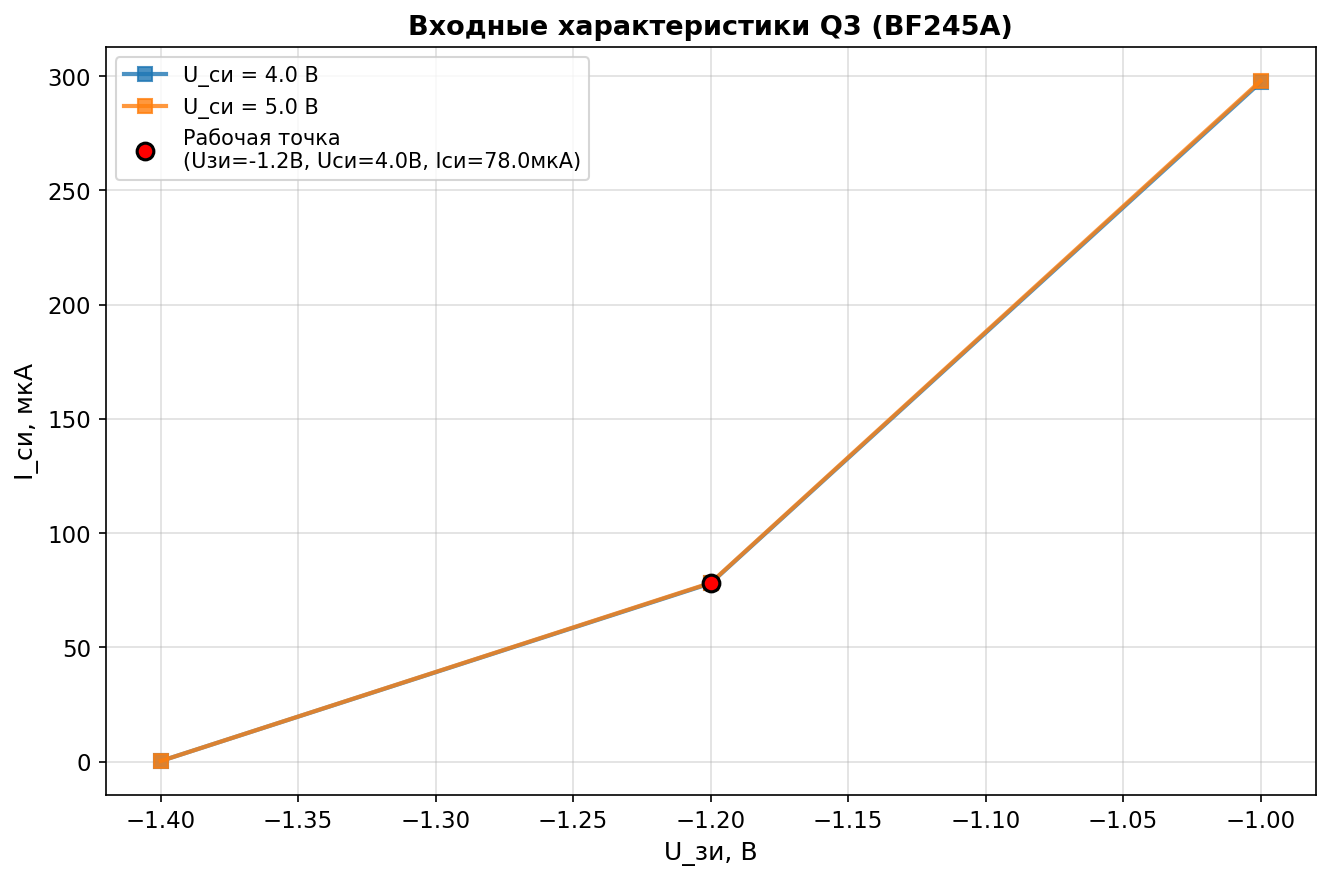

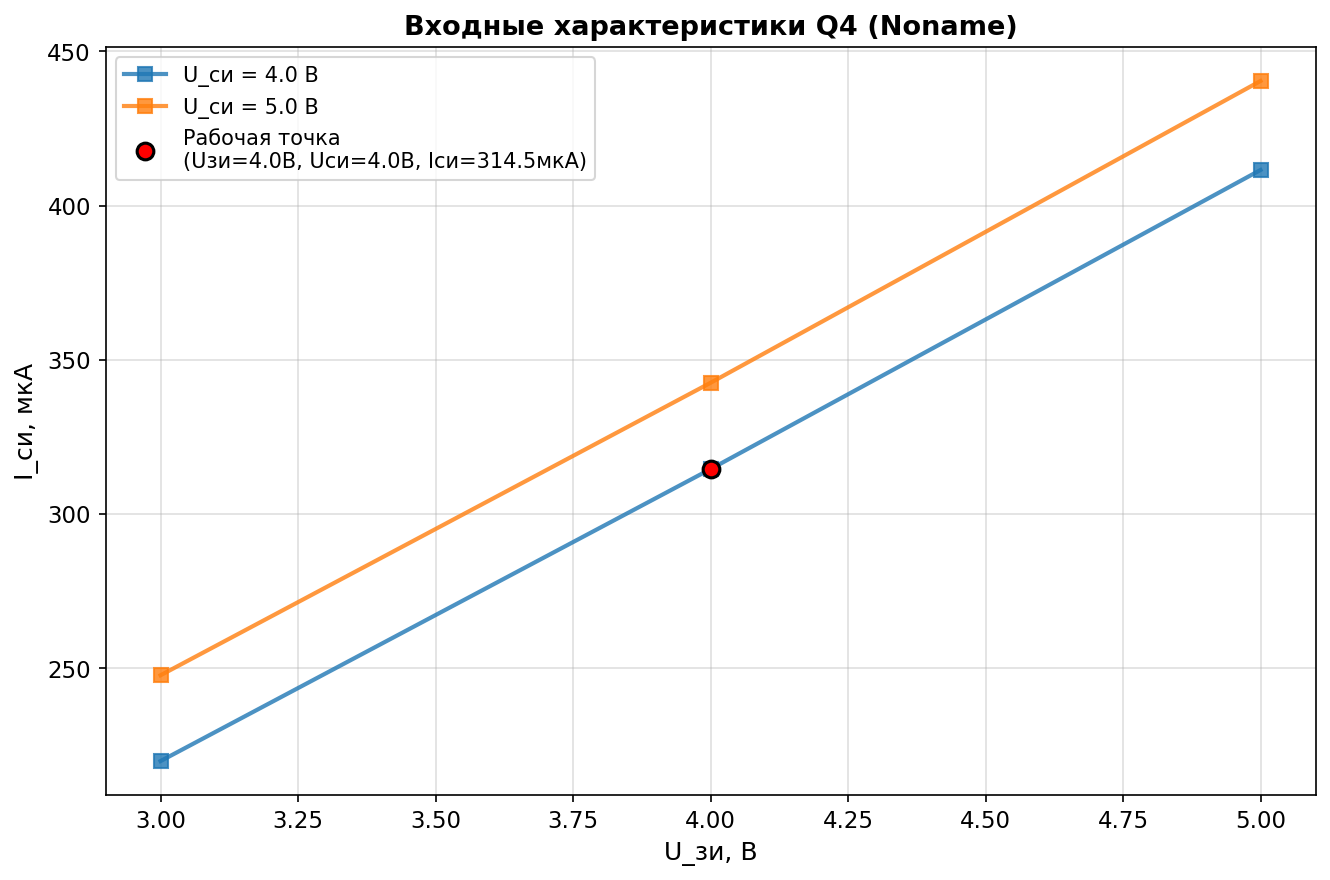


✅ ГРАФИКИ ПОСТРОЕНЫ!
📁 Сохраненные файлы:
   - out_q3_plus.png (выходные Q3)
   - out_q4_plus.png (выходные Q4)
   - in_q3.png (входные Q3)
   - in_q4.png (входные Q4)

📊 На всех графиках:
   • Кружками/квадратами отмечены все измеренные точки
   • Красной точкой отмечена рабочая точка с током Iси


In [8]:
# -*- coding: utf-8 -*-
"""
Лабораторная работа: Изучение характеристик полевых транзисторов
Вариант 17 | Полный комплект (Графики + Расчёты)
Студент: Мэттью Риммер | Группа: БББО-23-24
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# ==================== НАСТРОЙКИ ====================
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (9, 6)
plt.rcParams['figure.dpi'] = 150
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Рабочая точка
Q3_QPOINT = {'Ugs': -1.2, 'Uds': 4.0}
Q4_QPOINT = {'Ugs': 4.0, 'Uds': 4.0}

# ==================== ДАННЫЕ (ТОЛЬКО V+, все в мкА) ====================

# Q3 (BF245A)
# Опыт 5 (Uзи = -1.0В)
q3_v10_U = np.array([0, 0.705, 1.7, 2.7, 3.7, 4.7, 5.7, 6.7, 7.7, 8.7, 9.7])
q3_v10_I = np.array([0, 294, 295, 296, 297, 297.8, 298, 299, 300.1, 300.9, 301])

# Опыт 7 (Uзи = -1.2В)
q3_v12_U = np.array([0, 0.922, 1.92, 2.92, 3.92, 4.92, 5.92, 6.92, 7.92, 8.92, 9.92])
q3_v12_I = np.array([0, 77.4, 77.6, 77.8, 78, 78.2, 78.4, 78.6, 78.8, 79, 79.2])

# Опыт 9 (Uзи = -1.4В) [нА → мкА]
q3_v14_U = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
q3_v14_I = np.array([0, 253.1, 253.7, 254.3, 255.1, 255.7, 256.4, 257.1, 257.7, 258.4, 259]) * 0.001

data_Q3 = {
    -1.0: (q3_v10_U, q3_v10_I),
    -1.2: (q3_v12_U, q3_v12_I),
    -1.4: (q3_v14_U, q3_v14_I)
}

# Q4 (Noname)
# Опыт 11 (Uзи = 3В)
q4_v3_U = np.array([0, 0.869, 1.84, 2.81, 3.79, 4.76, 5.73, 6.70, 7.68, 8.65, 9.62])
q4_v3_I = np.array([0, 130, 162, 188, 214, 241, 268, 295, 323, 350, 378])

# Опыт 13 (Uзи = 4В)
q4_v4_U = np.array([0, 0.808, 1.75, 2.72, 3.69, 4.67, 5.64, 6.61, 7.58, 8.55, 9.53])
q4_v4_I = np.array([0, 191, 251, 279, 306, 333, 361, 389, 417, 445, 473])

# Опыт 15 (Uзи = 5В)
q4_v5_U = np.array([0, 0.756, 1.66, 2.63, 3.6, 4.57, 5.54, 6.52, 7.5, 8.46, 9.43])
q4_v5_I = np.array([0, 243, 344, 372, 400, 428, 456, 484, 512, 540, 569])

data_Q4 = {
    3.0: (q4_v3_U, q4_v3_I),
    4.0: (q4_v4_U, q4_v4_I),
    5.0: (q4_v5_U, q4_v5_I)
}

# ==================== ФУНКЦИИ ГРАФИКОВ ====================

def plot_output_characteristics(data_dict, q_point, title, filename):
    """Выходные характеристики с ОТМЕЧЕННЫМИ всеми точками"""
    plt.figure()
    
    for i, (Ugs, (U_data, I_data)) in enumerate(sorted(data_dict.items())):
        # Рисуем линию через все точки
        plt.plot(U_data, I_data, marker='o', markersize=5, 
                label=f'U_зи = {Ugs:+.1f} В', color=COLORS[i % len(COLORS)], 
                linewidth=1.5, alpha=0.8)
    
    # Отмечаем рабочую точку (большая красная точка)
    ugs_q, uds_q = q_point['Ugs'], q_point['Uds']
    U_q, I_q = data_dict[ugs_q]
    f_interp = interp1d(U_q, I_q, bounds_error=False, fill_value='extrapolate')
    ids_q = f_interp(uds_q)
    
    plt.plot(uds_q, ids_q, marker='o', markersize=8, color='red', 
            markeredgecolor='black', markeredgewidth=1.5, linewidth=0,
            label=f'Рабочая точка\n(Uси={uds_q}В, Uзи={ugs_q:+.1f}В, Iси={ids_q:.1f}мкА)', zorder=10)
    
    plt.grid(True, alpha=0.4)
    plt.xlabel('U_си, В', fontsize=12)
    plt.ylabel('I_си, мкА', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

def plot_input_characteristics(data_dict, uds_targets, q_ugs, title, filename):
    """Входные характеристики с отмеченными расчетными точками"""
    plt.figure(figsize=(9, 6))
    
    # Для каждого Uси строим входную характеристику
    for idx, uds_target in enumerate(uds_targets):
        ugs_values = []
        ids_values = []
        
        for ugs in sorted(data_dict.keys()):
            U_data, I_data = data_dict[ugs]
            f_interp = interp1d(U_data, I_data, bounds_error=False, fill_value='extrapolate')
            ids_at_target = f_interp(uds_target)
            ugs_values.append(ugs)
            ids_values.append(ids_at_target)
        
        # Рисуем линию и отмечаем точки
        plt.plot(ugs_values, ids_values, marker='s', markersize=7, 
                linewidth=2, label=f'U_си = {uds_target} В',
                color=COLORS[idx], alpha=0.8)
    
    # Отмечаем рабочую точку (на кривой Uси = 4В)
    uds_q = 4.0
    ugs_list = sorted(data_dict.keys())
    ids_at_4v = []
    for ugs in ugs_list:
        U_data, I_data = data_dict[ugs]
        f = interp1d(U_data, I_data, bounds_error=False, fill_value='extrapolate')
        ids_at_4v.append(f(4.0))
    
    f_input = interp1d(ugs_list, ids_at_4v, bounds_error=False, fill_value='extrapolate')
    ids_q = f_input(q_ugs)
    
    plt.plot(q_ugs, ids_q, marker='o', markersize=8, color='red', 
            markeredgecolor='black', markeredgewidth=1.5, linewidth=0,
            label=f'Рабочая точка\n(Uзи={q_ugs}В, Uси={uds_q}В, Iси={ids_q:.1f}мкА)', zorder=10)
    
    plt.grid(True, alpha=0.4)
    plt.xlabel('U_зи, В', fontsize=12)
    plt.ylabel('I_си, мкА', fontsize=12)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()

# ==================== ЗАПУСК ====================

if __name__ == "__main__":
    print("🔬 Лабораторная работа: Вариант 17")
    print("📌 Рабочие точки: Q3(Uзи=-1.2В, Uси=4.0В) | Q4(Uзи=4.0В, Uси=4.0В)")
    print("📊 На графиках отмечены ВСЕ измеренные точки")
    print("📈 Только положительные ветви (V+)")
    
    # 1. ВЫХОДНЫЕ ХАРАКТЕРИСТИКИ (только V+)
    print("\n📈 Построение выходных характеристик (V+)...")
    plot_output_characteristics(data_Q3, Q3_QPOINT, 
                               "Выходные характеристики Q3 (BF245A)", 
                               "out_q3_plus.png")
    plot_output_characteristics(data_Q4, Q4_QPOINT,
                               "Выходные характеристики Q4 (Noname)",
                               "out_q4_plus.png")
    
    # 2. ВХОДНЫЕ ХАРАКТЕРИСТИКИ
    print("\n📈 Построение входных характеристик...")
    plot_input_characteristics(data_Q3, [4.0, 5.0], -1.2,
                              "Входные характеристики Q3 (BF245A)",
                              "in_q3.png")
    plot_input_characteristics(data_Q4, [4.0, 5.0], 4.0,
                              "Входные характеристики Q4 (Noname)",
                              "in_q4.png")
    
    print("\n" + "="*60)
    print("✅ ГРАФИКИ ПОСТРОЕНЫ!")
    print("📁 Сохраненные файлы:")
    print("   - out_q3_plus.png (выходные Q3)")
    print("   - out_q4_plus.png (выходные Q4)")
    print("   - in_q3.png (входные Q3)")
    print("   - in_q4.png (входные Q4)")
    print("\n📊 На всех графиках:")
    print("   • Кружками/квадратами отмечены все измеренные точки")
    print("   • Красной точкой отмечена рабочая точка с током Iси")
    print("="*60)